In [105]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="keras.src.export.tf2onnx_lib"
)
import tensorflow as tf
import pandas as pd
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Conv2D, LSTM, Input, MaxPooling2D, Reshape, Bidirectional, StringLookup
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard
import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.constants import *
from src.helpers import load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras.backend import ctc_batch_cost, int_shape, ctc_decode
import editdistance

### File paths and labels

In [106]:
df = pd.read_csv(TRAIN_TSV, sep='\t', header=None, names=['file', 'label'])
df = df.dropna(subset=['label']).reset_index(drop=True) # 2 entries with no label
image_paths = [TRAIN_DIR + "/" + f for f in df["file"].values]
labels = df["label"].values

df

,file,label
0,aa1.png,Молдова
1,aa1007.png,продолжила борьбу
2,aa101.png,разработанные
3,aa1012.png,Плачи
4,aa1013.png,Гимны богам
...,...,...
72279,yob20539.png,Ответственность в/сл-
72280,yob20543.png,независимо
72281,yob20544.png,от воинского звания
72282,yob20545.png,воинской


### Alphabet of possible values

In [107]:
import unicodedata
chars = list(set(char for label in labels for char in label))

for char in chars:
    script = unicodedata.name(char, 'idk')
    print(f"{char}: {script}")

max([len(label) for label in labels]) # the kaggle page said 40, this is just to confirm it
#len(chars) 107

К: CYRILLIC CAPITAL LETTER KA
o: LATIN SMALL LETTER O
э: CYRILLIC SMALL LETTER E
3: DIGIT THREE
щ: CYRILLIC SMALL LETTER SHCHA
З: CYRILLIC CAPITAL LETTER ZE
д: CYRILLIC SMALL LETTER DE
Й: CYRILLIC CAPITAL LETTER SHORT I
b: LATIN SMALL LETTER B
Ю: CYRILLIC CAPITAL LETTER YU
Ч: CYRILLIC CAPITAL LETTER CHE
.: FULL STOP
Е: CYRILLIC CAPITAL LETTER IE
Я: CYRILLIC CAPITAL LETTER YA
ф: CYRILLIC SMALL LETTER EF
м: CYRILLIC SMALL LETTER EM
А: CYRILLIC CAPITAL LETTER A
я: CYRILLIC SMALL LETTER YA
»: RIGHT-POINTING DOUBLE ANGLE QUOTATION MARK
=: EQUALS SIGN
': APOSTROPHE
Б: CYRILLIC CAPITAL LETTER BE
ё: CYRILLIC SMALL LETTER IO
М: CYRILLIC CAPITAL LETTER EM
П: CYRILLIC CAPITAL LETTER PE
р: CYRILLIC SMALL LETTER ER
в: CYRILLIC SMALL LETTER VE
1: DIGIT ONE
R: LATIN CAPITAL LETTER R
 : SPACE
!: EXCLAMATION MARK
4: DIGIT FOUR
ы: CYRILLIC SMALL LETTER YERU
Д: CYRILLIC CAPITAL LETTER DE
И: CYRILLIC CAPITAL LETTER I
p: LATIN SMALL LETTER P
н: CYRILLIC SMALL LETTER EN
й: CYRILLIC SMALL LETTER SHORT I
Р: C

40

In [108]:
label_to_int = StringLookup(vocabulary=chars, num_oov_indices=0) # encode
label_to_str = StringLookup(vocabulary=label_to_int.get_vocabulary(), invert=True) # decode

### Dataset

In [109]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        factor= 2/180.0,
        fill_mode="reflect",
    ),
    tf.keras.layers.RandomZoom(
        height_factor= 0.0,
        width_factor= (-0.05, 0.05),
        fill_mode="reflect",
    ),
    tf.keras.layers.RandomContrast(0.15),
])

In [110]:
def build_dataset(paths, labels, batch_size, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(1024)

    def load_and_process(p, y):
        img = load_img(p)
        y = label_to_int(tf.strings.unicode_split(y, input_encoding="UTF-8"))
        y = tf.cast(y, tf.int32) + 1
        if training:
            img = augmentation(img, training=True)
        return {"img_input": img, "label_input": y}, y

    ds = ds.map(load_and_process, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.padded_batch(batch_size, padded_shapes=({"img_input": [IM_HEIGHT, IM_WIDTH, 1], "label_input": [None]}, [None]),
        padding_values=({"img_input": 0.0, "label_input": 0}, 0)
    )
    
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

### 80/20 train dataset split

In [111]:
# TODO: REMOVE CUTOFF LATER
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths[:1500], labels[:1500], test_size=VALIDATION_SIZE, random_state=67)

train_ds = build_dataset(train_paths, train_labels, batch_size=32, training=True)
val_ds = build_dataset(val_paths, val_labels, batch_size=32, training=False)

### Model

In [112]:
class CTCLayer(tf.keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_func = ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_size = tf.cast(tf.shape(y_true)[0], tf.int32)
        input_len = tf.cast(tf.shape(y_pred)[1], tf.int32)
        input_len *= tf.ones((batch_size, 1), tf.int32)

        label_len = tf.math.count_nonzero(y_true, axis=1, keepdims=True)
        
        loss = self.loss_func(y_true, y_pred, input_len, label_len)
        self.add_loss(loss)
        return y_pred

In [113]:
# this is for the gradient norm metric later
# class OCRModel(tf.keras.Model):
#     def train_step(self, data):
#         inputs = data[0]

#         with tf.GradientTape() as tape:
#             y_pred = self(inputs, training=True)
#             loss = tf.reduce_mean(sum(self.losses))
#         grads = tape.gradient(loss, self.trainable_variables)

#         grad_norm = tf.linalg.global_norm(grads)
#         self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
#         return {"loss": loss, "grad_norm": grad_norm}
    
#     def test_step(self, data):
#         print(data)
#         inputs = data[0]
#         y_pred = self(inputs, training=False)
#         loss = tf.reduce_mean(sum(self.losses))
#         return {"loss": loss}

In [114]:
img_input = Input(shape=(IM_HEIGHT, IM_WIDTH, 1), name="img_input")
label_input = Input(shape=(None,), dtype=tf.int32, name="label_input")

# stride for a more general overview of the image, more precise conv later
x = Conv2D(64, 5, strides=2, padding="same", activation=tf.nn.leaky_relu, name="conv1")(img_input)
x = MaxPooling2D(name="pool1")(x)

x = Conv2D(64, 3, padding="same", activation=tf.nn.leaky_relu, name="conv2")(x)
x = MaxPooling2D(name="pool2")(x)

shape = int_shape(x)
h, w, c = shape[1], shape[2], shape[3]
x = Reshape(target_shape=(w, h * c), name="shape1")(x)
x = Dense(192, activation=tf.nn.leaky_relu, name="dense1")(x)

x = Bidirectional(LSTM(256, return_sequences=True), name="lstm1")(x)
x = Bidirectional(LSTM(128, return_sequences=True), name="lstm2")(x)

x = Dense(len(chars)+2, activation="softmax", name="softmax")(x) # +1 for the blank char and +1 for padding

output = CTCLayer(name="ctc")(label_input, x)

model = Model(inputs=[img_input, label_input], outputs=output)
model.compile(optimizer="adam")
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 200, 800,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 100, 400,  │      1,664 │ img_input[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 50, 200,   │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 50, 200,   │     36,928 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 25, 100,   │          0 │ conv2[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shape1 (Reshape)    │ (None, 100, 1600) │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 100, 192)  │    307,392 │ shape1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm1               │ (None, 100, 512)  │    919,552 │ dense1[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm2               │ (None, 100, 256)  │    656,384 │ lstm1[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_input         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Dense)     │ (None, 100, 109)  │     28,013 │ lstm2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc (CTCLayer)      │ (None, 100, 109)  │          0 │ label_input[0][0… │
│                     │                   │            │ softmax[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,949,933 (7.44 MB)

 Trainable params: 1,949,933 (7.44 MB)

 Non-trainable params: 0 (0.00 B)

### Overfitting experiment

In [115]:
overfit_ds = build_dataset(train_paths[:5], train_labels[:5], 5, False)
# for input, _ in overfit_ds.take(1):
    # print(input['img_input'].shape)
    # print(input['label_input'].shape)
    # print(label_to_str(input['label_input']))

model.fit(overfit_ds, validation_data=overfit_ds, epochs=1000, callbacks=[callbacks])


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2197.51611

['причине', 'снова', 'т.к.', 'ство', 'что']
['', '', '', '', '']
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 2197.5161 - val_loss: 1937.8590 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - val_blank_ratio: 1.0000
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 1937.85901

['причине', 'снова', 'т.к.', 'ство', 'что']
['', '', '', '', '']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - loss: 1937.8590 - val_loss: 1073.4597 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - val_blank_ratio: 1.0000
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 1073.45971

['причине', 'снова', 'т.к.', 'ство', 'что']
['', '', '', '', '']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - loss: 1073.4597 - val_loss: 190.2727 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - val_blank_ratio: 1.0000
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 190.27271

['причине', 'снова', 'т.к.', 'ство', 'что']
['', '', '', '', '']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

KeyboardInterrupt: 

In [119]:
y_pred = model.predict(overfit_ds)
def decode_output(y_pred) -> list[str]:
    input_len = np.ones(y_pred.shape[0]) * y_pred.shape[1]
    decoded, _ = tf.keras.backend.ctc_decode(y_pred, input_len, greedy=True)

    res = []
    for seq in decoded[0].numpy():
        seq = seq[seq != -1]
        text = b"".join(label_to_str(seq).numpy()).decode("utf-8")
        res.append(text)
    return res

print(decode_output(y_pred))
print(list(train_labels[:5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
['приине', 'снова', 'т.к.', 'ство', 'что']
['причине', 'снова', 'т.к.', 'ство', 'что']


['Гимны богам', 'разработанные', 'продолжила борьбу', 'Плачи']
Real label: Гимны богам


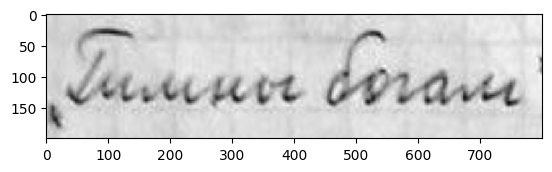

In [ ]:
for input, _ in overfit_ds.take(1):
    plt.imshow(input['img_input'][0, :, :, 0], cmap="gray", interpolation="nearest")
    print(f"Real label: {train_labels[0]}")

# Actual training

### Metrics

###  Performance: character error rate, exact word match
### Training: learning rate, gradient norm (defined earlier), blank ratio

In [ ]:
class CustomCallbacks(tf.keras.callbacks.Callback):
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs):
        # predicting and getting the true labels
        truths = []
        preds = []
        preds_probs = []
        print(len(self.val_ds))
        for imgs, labels in self.val_ds:
            pred = self.model(imgs, training=False)
            preds_probs.append(pred)
            preds.extend(decode_output(pred))
            for seq in labels.numpy():
                seq = seq[seq != 0]
                truths.append(b"".join(label_to_str(seq).numpy()).decode("utf-8"))

        # Character error rate (average levenshtein distance, the lower the better)
        total_edits = 0
        total_chars = 0
        for p, t in zip(preds, truths):
            total_edits += editdistance.eval(p, t)
            total_chars += len(t)
        cer = total_edits / max(1, total_chars)
        
        # Exact word match (the higher the better)
        correct = sum(p == t for p, t in zip(preds, truths))
        ewm = correct / max(1, len(truths))

        # Blank ratio (how many characters are being predicted as blanks)
        # (generally the lower the better)
        logits = tf.concat(preds_probs, axis=0)
        pred_ids = tf.argmax(logits, axis=-1)
        blank_idx = logits.shape[-1] - 1
        blanks = tf.equal(pred_ids, blank_idx)
        blank_cnt = tf.reduce_sum(tf.cast(blanks, tf.float32))
        total_steps = tf.cast(tf.size(pred_ids), tf.float32)
        blank_ratio = (blank_cnt / tf.maximum(1., total_steps)).numpy()

        logs['val_cer'] = cer
        logs['val_ewm'] = ewm
        logs['val_blank_ratio'] = blank_ratio
        print()
        print(truths)
        print(preds)

callbacks = CustomCallbacks(overfit_ds)

In [ ]:
early = EarlyStopping(monitor="val_cer", patience=20, restore_best_weights=True)
reduce = ReduceLROnPlateau(monitor="val_cer", mode='min', factor=0.2, patience=5, min_lr=10e-6)
board = TensorBoard(log_dir=LOG_DIR)
callbacks = CustomCallbacks(val_ds) # learning rate logged by default with the reduce callback

model.fit(train_ds, validation_data=val_ds, epochs=500, callbacks=[callbacks, reduce, board])

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - grad_norm: 18.9978 - loss: 45.9845tf.Tensor(
[[108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108]], shape=(1, 100), dtype=int64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step - grad_norm: 18.9978 - loss: 45.9845 - val_loss: 33.6602 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - val_blank_ratio: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - grad_norm: 18.9653 - loss: 45.9489tf.Tensor(
[[108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108 108
  108 108 108 108 108 

KeyboardInterrupt: 

In [ ]:
y_pred = model.predict(overfit_ds)

print(decode_output(y_pred))
print(list(train_labels[:5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
['', '', '', '']
['Гимны богам', 'разработанные', 'продолжила борьбу', 'Плачи']
